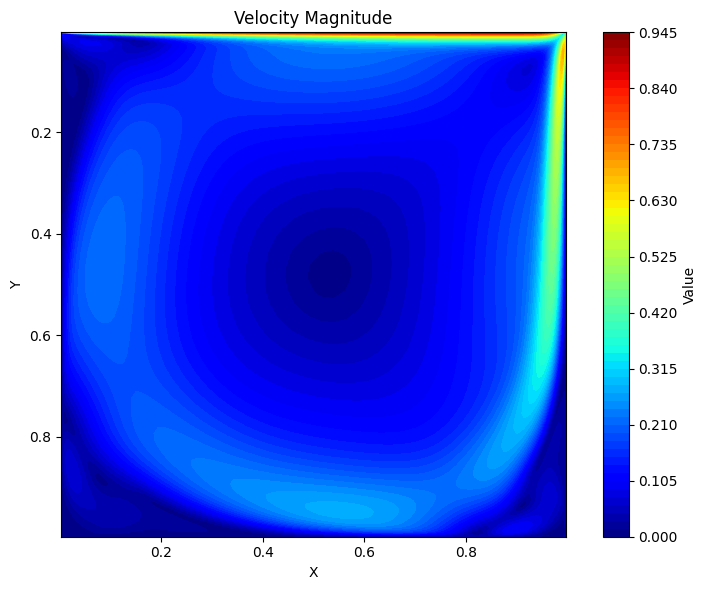

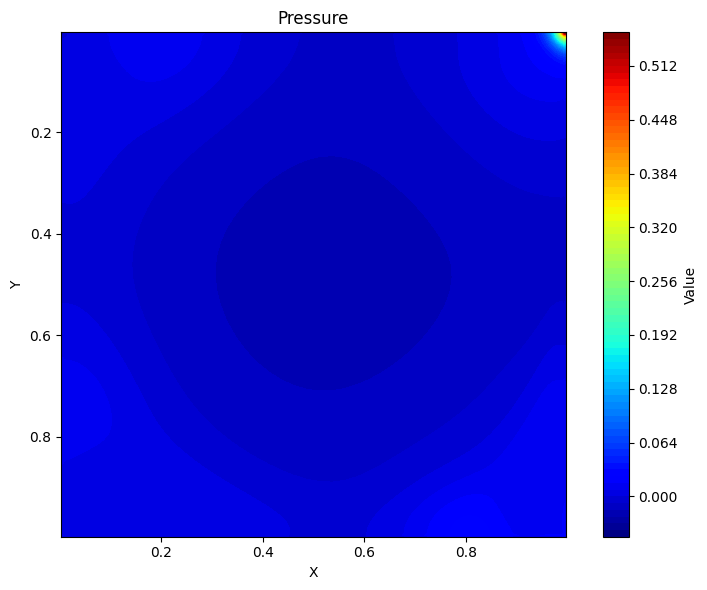

In [42]:
import numpy as np
import os
import matplotlib.pyplot as plt


def plot_contour(data, xc, yc, title, cmap='coolwarm'):
    fig, ax = plt.subplots(figsize=(8, 6))
    cs = ax.contourf(xc, yc, data, levels=80, cmap=cmap)
    fig.colorbar(cs, ax=ax, label='Value')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.invert_yaxis()          # y 向下为正
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()


def plot_contour2(data, xc, yc, title, cmap='coolwarm', vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    cs = ax.contourf(xc, yc, data, levels=80, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(cs, ax=ax, label='Value')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.invert_yaxis()          # y 向下为正
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()


def load_and_combine_data(n_splits):
    """
    拼接所有子进程的物理场和坐标文件。
    文件名格式：u_0.dat ... u_N.dat / xc_0.dat ... xc_N.dat 等
    边界 ghost 层裁切规则（与原代码一致）：
      rank 0     → 去掉右侧2列
      rank N     → 去掉左侧2列
      中间 rank  → 去掉两侧各2列
    """
    u_list, v_list, p_list = [], [], []
    xc_list, yc_list = [], []

    for idx in range(n_splits + 1):
        u  = np.loadtxt(f'u_{idx}.dat',  dtype=np.float64)
        v  = np.loadtxt(f'v_{idx}.dat',  dtype=np.float64)
        p  = np.loadtxt(f'p_{idx}.dat',  dtype=np.float64)
        xc = np.loadtxt(f'xc_{idx}.dat', dtype=np.float64)
        yc = np.loadtxt(f'yc_{idx}.dat', dtype=np.float64)

        if idx == 0:                    # 最左子域：去掉右侧2列 ghost
            sl = np.s_[:, :-2]
        elif idx == n_splits:           # 最右子域：去掉左侧2列 ghost
            sl = np.s_[:, 2:]
        else:                           # 中间子域：两侧各去2列 ghost
            sl = np.s_[:, 2:-2]

        u_list.append(u[sl]);   v_list.append(v[sl]);   p_list.append(p[sl])
        xc_list.append(xc[sl]); yc_list.append(yc[sl])

    u_all  = np.concatenate(u_list,  axis=1)
    v_all  = np.concatenate(v_list,  axis=1)
    p_all  = np.concatenate(p_list,  axis=1)
    xc_all = np.concatenate(xc_list, axis=1)
    yc_all = np.concatenate(yc_list, axis=1)

    return u_all, v_all, p_all, xc_all, yc_all


# ──────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    n_splits = int(input("请输入子进程数量 - 1（例如并行2个进程则输入1）: "))

    u, v, p, xc, yc = load_and_combine_data(n_splits)

    # 保存拼接结果
    np.savetxt('u_combined.dat',  u)
    np.savetxt('v_combined.dat',  v)
    np.savetxt('p_combined.dat',  p)
    np.savetxt('xc_combined.dat', xc)
    np.savetxt('yc_combined.dat', yc)

    # 速度大小
    vel_mag = np.sqrt(u**2 + v**2)

    # ── 裁掉最外一圈边界单元（与原逻辑保持一致）──
    vel_mag = vel_mag[1:-1, 1:-1]
    p       = p      [1:-1, 1:-1]
    xc      = xc     [1:-1, 1:-1]
    yc      = yc     [1:-1, 1:-1]

    plot_contour(vel_mag, xc, yc, 'Velocity Magnitude', cmap='jet')
    plot_contour(p,       xc, yc, 'Pressure',           cmap='jet')